In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import warnings
import xlrd
warnings.filterwarnings('ignore')

# Load data
data_path = r'C:\Users\Asus\OneDrive\Desktop\Rare_Earth_Elements\data\raw\BRS_Report.XLS'
df = pd.read_excel(data_path, engine='xlrd', header=1)

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())

Dataset Shape: (393, 12)

First few rows:
  S.No Sam.No Location       Latitude      Longitude Cu(ppm) Pb(ppm) Zn(ppm)  \
0    1  BRS-1      0/0  N27°40' 56.7"  E75°54' 19.3"     163     <50     139   
1    2  BRS-2     0/E1  N27°40' 55.5"  E75°54' 20.6"    1100     <50     120   
2    3  BRS-3     0/E2  N27°40' 54.6"  E75°54' 22.0"     580     <50      90   
3    4  BRS-4     0/E3  N27°40' 53.6"  E75°54' 24.1"     128     <50      54   
4    5  BRS-5     0/E4  N27°40' 52.9"  E75°54' 24.9"      21     <50      59   

  Ni(ppm) Co(ppm) Ag(ppm) Cd(ppm)  
0      51      25      <5      <5  
1      39     <25      <5      <5  
2      38     <25      <5      <5  
3      43     <25      <5      <5  
4      47      25      <5      <5  

Column names:
['S.No', 'Sam.No', 'Location', 'Latitude', 'Longitude', 'Cu(ppm)', 'Pb(ppm)', 'Zn(ppm)', 'Ni(ppm)', 'Co(ppm)', 'Ag(ppm)', 'Cd(ppm)']

Data types:
S.No         object
Sam.No          str
Location        str
Latitude        str
Longitude       str


In [3]:
import re

# Helper to parse material values like "<50", ">100", "163", "NA"
def parse_material(val):
    if pd.isna(val):
        return pd.NA
    s = str(val).strip()
    if s.upper() in {'NA', 'N/A', ''}:
        return pd.NA
    sign = 0
    if s.startswith('<'):
        sign = -1
        s = s[1:]
    elif s.startswith('>'):
        sign = 1
        s = s[1:]
    # extract first numeric token
    m = re.search(r'[\d.]+', s)
    if not m:
        return pd.NA
    try:
        num = float(m.group())
    except:
        return pd.NA
    # convert to integer and apply sign adjustment
    return int(round(num)) + sign

# Helper to parse DMS strings like "N27°40' 56.7\"" or "E75°54' 19.3\"" into decimal degrees
def parse_dms(coord):
    if pd.isna(coord):
        return np.nan
    s = str(coord).strip()
    # find hemisphere if present
    hemi_m = re.search(r'([NnSsEeWw])', s)
    hemi = hemi_m.group(1).upper() if hemi_m else None
    nums = re.findall(r'[\d.]+', s)
    if not nums:
        return np.nan
    deg = float(nums[0]) if len(nums) >= 1 else 0.0
    minute = float(nums[1]) if len(nums) >= 2 else 0.0
    sec = float(nums[2]) if len(nums) >= 3 else 0.0
    dd = deg + minute / 60.0 + sec / 3600.0
    if hemi in ('S', 'W'):
        dd = -dd
    return dd

# 1) Convert material columns: detect columns containing "(ppm)" and create short-name integer columns (e.g., "Cu")
material_cols = [c for c in df.columns if '(ppm)' in c]
for col in material_cols:
    short = col.split('(')[0].strip()
    df[short] = df[col].apply(parse_material).astype("Int64")

# 2) Parse Latitude/Longitude into decimal degrees and create stable float columns named 'latitude' and 'longitude'
# Try to handle cases where Lat/Lon are in different columns; use existing names if present
lat_col_candidates = [c for c in df.columns if c.lower() == 'latitude' or 'lat' in c.lower()]
lon_col_candidates = [c for c in df.columns if c.lower() == 'longitude' or 'lon' in c.lower()]

# Prefer exact matches 'Latitude' and 'Longitude' if available
lat_col = next((c for c in df.columns if c == 'Latitude'), lat_col_candidates[0] if lat_col_candidates else None)
lon_col = next((c for c in df.columns if c == 'Longitude'), lon_col_candidates[0] if lon_col_candidates else None)

if lat_col is None or lon_col is None:
    raise ValueError("Latitude or Longitude column not found. Available columns: " + ", ".join(df.columns))

df['latitude'] = df[lat_col].apply(parse_dms).astype(float)
df['longitude'] = df[lon_col].apply(parse_dms).astype(float)

# Quick sanity output
print("Converted material columns:", [c.split('(')[0].strip() for c in material_cols])
print("New dtypes (materials):")
for col in material_cols:
    short = col.split('(')[0].strip()
    print(f"  {short}: {df[short].dtype}")
print("\nLatitude/Longitude sample (decimal degrees):")
print(df[['latitude', 'longitude']].head())

Converted material columns: ['Cu', 'Pb', 'Zn', 'Ni', 'Co', 'Ag', 'Cd']
New dtypes (materials):
  Cu: Int64
  Pb: Int64
  Zn: Int64
  Ni: Int64
  Co: Int64
  Ag: Int64
  Cd: Int64

Latitude/Longitude sample (decimal degrees):
    latitude  longitude
0  27.682417  75.905361
1  27.682083  75.905722
2  27.681833  75.906111
3  27.681556  75.906694
4  27.681361  75.906917


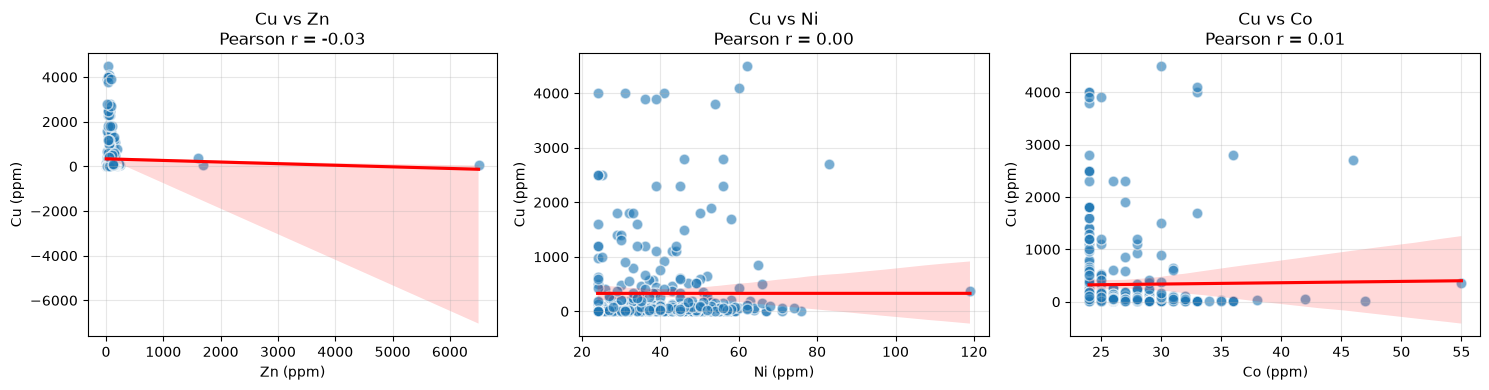

In [4]:
# Copper analytics versus other elements with scatter plots and regression lines
other_elements = [e for e in ['Zn', 'Ni', 'Co'] if e in df.columns and e != 'Cu']

if not other_elements:
    print("No other elements (Zn, Ni, Co) available for Copper analytics.")
else:
    fig, axes = plt.subplots(1, len(other_elements), figsize=(5 * len(other_elements), 4), squeeze=False)
    for ax, elem in zip(axes[0], other_elements):
        plot_df = df[['Cu', elem]].dropna()
        sns.regplot(
            data=plot_df,
            x=elem,
            y='Cu',
            ax=ax,
            scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 60},
            line_kws={'color': 'red'}
        )
        corr = plot_df['Cu'].corr(plot_df[elem])
        ax.set_title(f'Cu vs {elem}\nPearson r = {corr:.2f}')
        ax.set_xlabel(f'{elem} (ppm)')
        ax.set_ylabel('Cu (ppm)')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


=== COPPER ANALYSIS ===
Cu statistics:
count         364.0
mean     329.769231
std      754.044906
min             9.0
25%           10.75
50%            35.5
75%          195.75
max          4500.0
Name: Cu, dtype: Float64

Cu < 10 (Absent): 74
Cu >= 10 (Present): 290


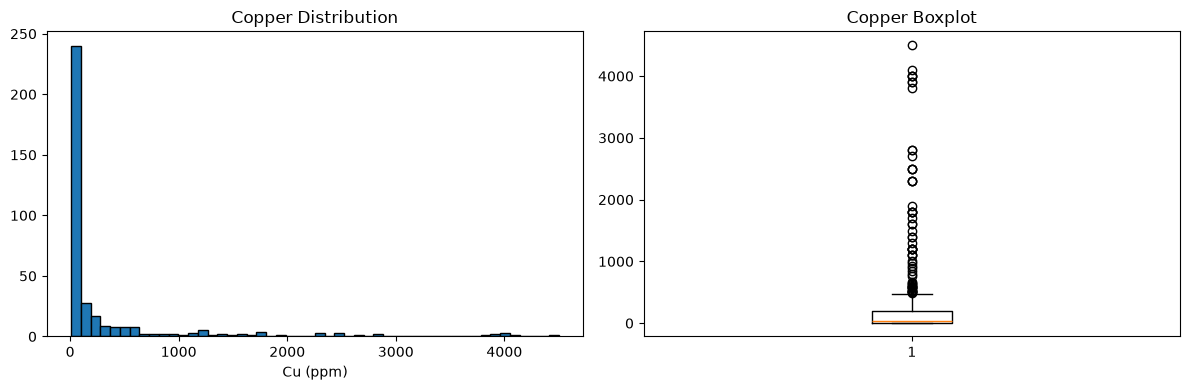


Elements availability: ['Zn', 'Ni', 'Co', 'Cu']

Longitude/Latitude available: True


In [5]:
# Check for copper column and key elements
print("\n=== COPPER ANALYSIS ===")
if 'Cu' in df.columns:
    print(f"Cu statistics:")
    print(df['Cu'].describe())
    print(f"\nCu < 10 (Absent): {(df['Cu'] < 10).sum()}")
    print(f"Cu >= 10 (Present): {(df['Cu'] >= 10).sum()}")
    
    # Visualize copper distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df['Cu'].dropna(), bins=50, edgecolor='black')
    axes[0].set_title('Copper Distribution')
    axes[0].set_xlabel('Cu (ppm)')
    axes[1].boxplot(df['Cu'].dropna())
    axes[1].set_title('Copper Boxplot')
    plt.tight_layout()
    plt.show()

# Check for elements
elements = ['Zn', 'Ni', 'Co', 'Cu']
print(f"\nElements availability: {[e for e in elements if e in df.columns]}")

# Check for coordinate columns
print(f"\nLongitude/Latitude available: {'longitude' in df.columns and 'latitude' in df.columns}")

In [6]:
# ===== DATA PREPARATION =====
# Identify blank/test rows (rows where Cu is NaN or empty)
test_mask = df['Cu'].isnull()
print(f"Test data (blank Cu rows): {test_mask.sum()}")
print(f"Train/Validation data: {(~test_mask).sum()}")

# Separate datasets
test_data = df[test_mask].copy()
train_val_data = df[~test_mask].copy()

print(f"\nTest set shape: {test_data.shape}")
print(f"Train/Val set shape: {train_val_data.shape}")

# Create target variable: Cu < 10 = 0 (absent), Cu >= 10 = 1 (present)
train_val_data['Cu_presence'] = (train_val_data['Cu'] >= 10).astype(int)
print(f"\nCopper Presence Distribution:")
print(train_val_data['Cu_presence'].value_counts())

# Store for later use
print("\n✓ Data split complete")

Test data (blank Cu rows): 29
Train/Validation data: 364

Test set shape: (29, 21)
Train/Val set shape: (364, 21)

Copper Presence Distribution:
Cu_presence
1    290
0     74
Name: count, dtype: int64

✓ Data split complete


In [7]:
# ===== FEATURE 1: Distance-weighted Copper Density Feature =====
# Find highest copper density spot
max_cu_idx = train_val_data['Cu'].idxmax()
max_cu_value = train_val_data.loc[max_cu_idx, 'Cu']
center_lat = train_val_data.loc[max_cu_idx, 'latitude']
center_lon = train_val_data.loc[max_cu_idx, 'longitude']

print(f"Highest Cu concentration: {max_cu_value} ppm at ({center_lat}, {center_lon})")

# Calculate distances from highest Cu spot for train/val data
def calculate_distances(data, center_lat, center_lon):
    """Calculate Euclidean distance from center point"""
    coords = data[['latitude', 'longitude']].values
    center = np.array([center_lat, center_lon])
    distances = np.sqrt(np.sum((coords - center) ** 2, axis=1))
    return distances

train_val_data['distance_from_max_cu'] = calculate_distances(
    train_val_data, center_lat, center_lon
)

# Initialize learnable parameters (these will be optimized later)
# For now, set reasonable initial values
N = 10**3  # Learnable parameter (amplitude)
k = 0.95  # Learnable parameter (decay rate, should be < 1)

# Feature 1: w = N * (d^k) / m_max
m_max = max_cu_value
train_val_data['feature_cu_proximity'] = N * (train_val_data['distance_from_max_cu'] ** k) / m_max

# # Also for test data
# test_data['distance_from_max_cu'] = calculate_distances(
#     test_data, center_lat, center_lon
# )
# test_data['feature_cu_proximity'] = N * (test_data['distance_from_max_cu'] ** k) / m_max

print(f"\nFeature 1 (Cu Proximity) created")
print(f"Train/Val Feature 1 stats: min={train_val_data['feature_cu_proximity'].min():.6f}, max={train_val_data['feature_cu_proximity'].max():.6f}")
# print(f"Test Feature 1 stats: min={test_data['feature_cu_proximity'].min():.6f}, max={test_data['feature_cu_proximity'].max():.6f}")

Highest Cu concentration: 4500 ppm at (27.696694444444443, 75.90855555555557)

Feature 1 (Cu Proximity) created
Train/Val Feature 1 stats: min=0.000000, max=0.009386


In [8]:
# ===== FEATURE 2: PCA of Key Elements =====
elements = ['Zn', 'Ni', 'Co', 'Cu']
available_elements = [e for e in elements if e in train_val_data.columns]

print(f"Available elements for PCA: {available_elements}")
print(f"Missing from data: {[e for e in elements if e not in train_val_data.columns]}")

# Prepare data for PCA (remove rows with missing element values)
element_data_train = train_val_data[available_elements].copy()
valid_idx_train = element_data_train.notna().all(axis=1)
element_data_clean_train = element_data_train[valid_idx_train].copy()

# element_data_test = test_data[available_elements].copy()
# valid_idx_test = element_data_test.notna().all(axis=1)
# element_data_clean_test = element_data_test[valid_idx_test].copy()

print(f"\nRows with complete element data (train/val): {valid_idx_train.sum()}/{len(train_val_data)}")
# print(f"Rows with complete element data (test): {valid_idx_test.sum()}/{len(test_data)}")

# Standardize the data
scaler = StandardScaler()
element_data_scaled_train = scaler.fit_transform(element_data_clean_train)

# Apply PCA
pca = PCA(n_components=min(4, len(available_elements)))
pca_train = pca.fit_transform(element_data_scaled_train)

# Get PC1 (first principal component)
train_val_data.loc[valid_idx_train, 'feature_pca_pc1'] = pca_train[:, 0]

# #Transform test data using the same scaler and PCA
# element_data_scaled_test = scaler.transform(element_data_clean_test)
# pca_test = pca.transform(element_data_scaled_test)
# test_data.loc[valid_idx_test, 'feature_pca_pc1'] = pca_test[:, 0]

# Fill missing PC1 values with mean (for rows without complete element data)
train_val_pc1_mean = train_val_data['feature_pca_pc1'].mean()
# test_pc1_mean = test_data['feature_pca_pc1'].mean()

train_val_data['feature_pca_pc1'].fillna(train_val_pc1_mean, inplace=True)
# test_data['feature_pca_pc1'].fillna(test_pc1_mean, inplace=True)

print(f"\nPCA Variance explained: {pca.explained_variance_ratio_}")
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.2%} of variance")

print(f"\nFeature 2 (PCA PC1) created")
print(f"Train/Val Feature 2 stats: min={train_val_data['feature_pca_pc1'].min():.4f}, max={train_val_data['feature_pca_pc1'].max():.4f}")
# print(f"Test Feature 2 stats: min={test_data['feature_pca_pc1'].min():.4f}, max={test_data['feature_pca_pc1'].max():.4f}")

Available elements for PCA: ['Zn', 'Ni', 'Co', 'Cu']
Missing from data: []

Rows with complete element data (train/val): 364/364

PCA Variance explained: [0.42143179 0.252669   0.22653373 0.09936548]
PC1 explains 42.14% of variance

Feature 2 (PCA PC1) created
Train/Val Feature 2 stats: min=-1.4480, max=10.7468


In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import xgboost as xgb
import lightgbm as lgb

# Prepare training data
X_train = train_val_data[['feature_cu_proximity', 'feature_pca_pc1']].values
y_train = train_val_data['Cu_presence'].values

# Split into train and validation
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"Train set: {X_tr.shape[0]}, Validation set: {X_val.shape[0]}")
print(f"Train class distribution: {np.bincount(y_tr)}")
print(f"Val class distribution: {np.bincount(y_val)}")

# ===== TRAIN MODELS =====
models = {}

# 1. XGBoost
print("\n=== Training XGBoost ===")
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                               random_state=42, eval_metric='logloss', verbosity=0)
xgb_model.fit(X_tr, y_tr)
xgb_pred_val = xgb_model.predict_proba(X_val)[:, 1]
print(f"XGBoost Val AUC: {roc_auc_score(y_val, xgb_pred_val):.4f}")
models['xgb'] = xgb_model

# 2. LightGBM
print("=== Training LightGBM ===")
lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                                random_state=42, verbosity=-1)
lgb_model.fit(X_tr, y_tr)
lgb_pred_val = lgb_model.predict_proba(X_val)[:, 1]
print(f"LightGBM Val AUC: {roc_auc_score(y_val, lgb_pred_val):.4f}")
models['lgb'] = lgb_model

# 3. Random Forest
print("=== Training Random Forest ===")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf_model.fit(X_tr, y_tr)
rf_pred_val = rf_model.predict_proba(X_val)[:, 1]
print(f"Random Forest Val AUC: {roc_auc_score(y_val, rf_pred_val):.4f}")
models['rf'] = rf_model

# 4. Ensemble (Voting)
from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[('xgb', xgb_model), ('lgb', lgb_model), ('rf', rf_model)],
    voting='soft'
)
ensemble_model.fit(X_tr, y_tr)
ensemble_pred_val = ensemble_model.predict_proba(X_val)[:, 1]
print(f"Ensemble Val AUC: {roc_auc_score(y_val, ensemble_pred_val):.4f}")
models['ensemble'] = ensemble_model

print("\n✓ All models trained")

Train set: 291, Validation set: 73
Train class distribution: [ 59 232]
Val class distribution: [15 58]

=== Training XGBoost ===
XGBoost Val AUC: 0.7724
=== Training LightGBM ===
LightGBM Val AUC: 0.8126
=== Training Random Forest ===
Random Forest Val AUC: 0.8115
Ensemble Val AUC: 0.8115

✓ All models trained



=== VALIDATION RESULTS ===

Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.20      0.32        15
           1       0.83      0.98      0.90        58

    accuracy                           0.82        73
   macro avg       0.79      0.59      0.61        73
weighted avg       0.81      0.82      0.78        73


Confusion Matrix:
[[ 3 12]
 [ 1 57]]


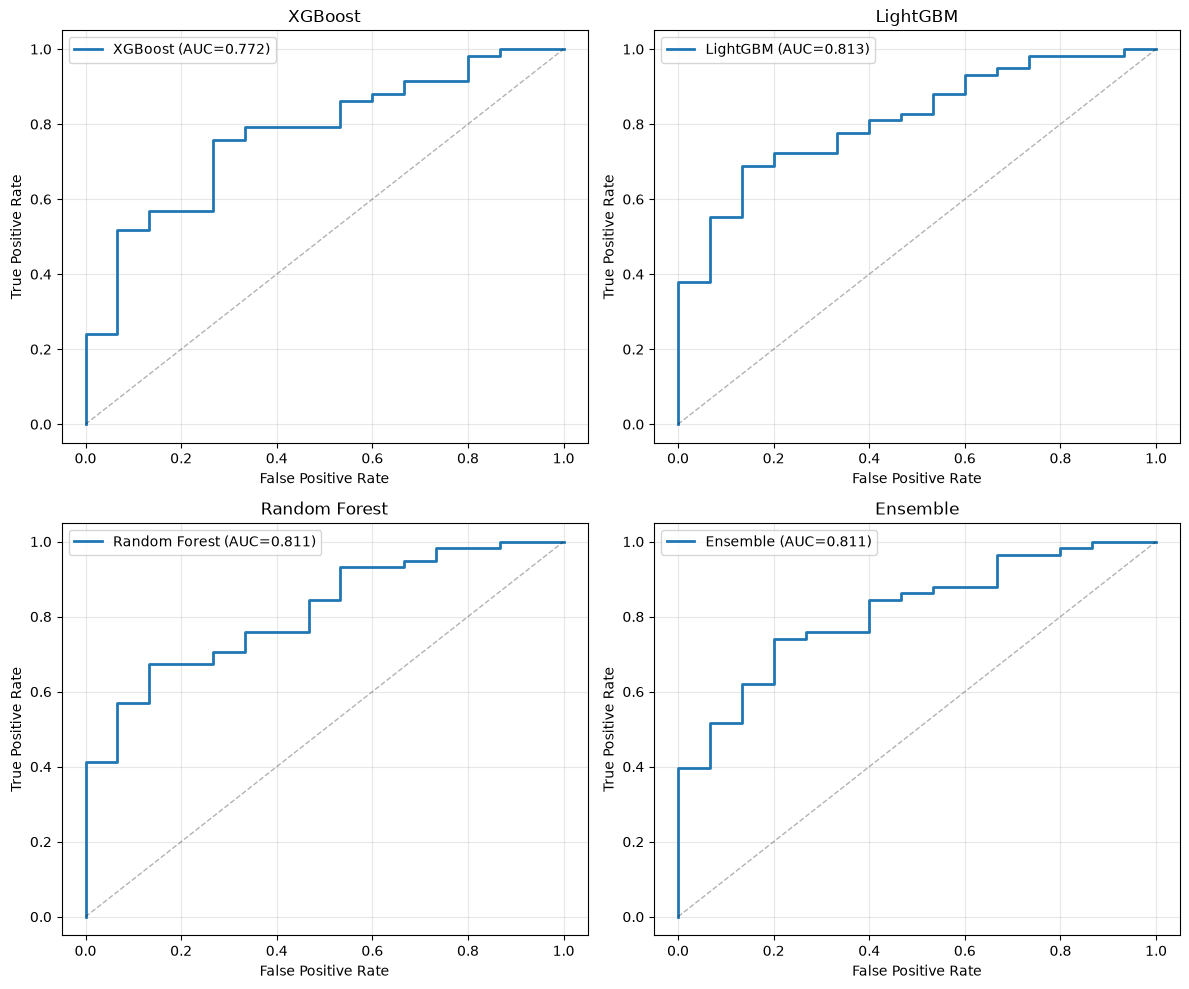


Validation Results Summary:
       actual_cu_presence  predicted_cu_presence  probability_present  \
count           73.000000              73.000000            73.000000   
mean             0.794521               0.945205             0.817771   
std              0.406848               0.229154             0.177853   
min              0.000000               0.000000             0.152850   
25%              1.000000               1.000000             0.740727   
50%              1.000000               1.000000             0.863875   
75%              1.000000               1.000000             0.972807   
max              1.000000               1.000000             0.993099   

       feature_cu_proximity  feature_pca_pc1  
count             66.000000        73.000000  
mean               0.004424         0.060458  
std                0.002551         1.665853  
min                0.000097        -1.440180  
25%                0.002186        -0.807523  
50%                0.004167    

In [10]:
# ===== VALIDATION PREDICTIONS & EVALUATION =====
print("\n=== VALIDATION RESULTS ===")

# Get predictions from ensemble (best overall approach)
y_pred_ensemble = ensemble_model.predict(X_val)
y_pred_proba_ensemble = ensemble_model.predict_proba(X_val)[:, 1]

print("\nEnsemble Classification Report:")
print(classification_report(y_val, y_pred_ensemble))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_pred_ensemble)
print(cm)

# Plot ROC curves for all models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

model_names = ['XGBoost', 'LightGBM', 'Random Forest', 'Ensemble']
model_list = [xgb_model, lgb_model, rf_model, ensemble_model]
pred_list = [xgb_pred_val, lgb_pred_val, rf_pred_val, ensemble_pred_val]

for idx, (ax, name, model, pred) in enumerate(zip(axes.flat, model_names, model_list, pred_list)):
    auc = roc_auc_score(y_val, pred)
    fpr, tpr, _ = roc_curve(y_val, pred)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Store ensemble predictions for validation data
val_results = pd.DataFrame({
    'actual_cu_presence': y_val,
    'predicted_cu_presence': y_pred_ensemble,
    'probability_present': y_pred_proba_ensemble,
    'feature_cu_proximity': X_val[:, 0],
    'feature_pca_pc1': X_val[:, 1]
})

print("\nValidation Results Summary:")
print(val_results.describe())

In [11]:
# # ===== TEST PREDICTIONS =====
# print("\n=== TEST PREDICTIONS ===")

# # Prepare test features
# X_test = test_data[['feature_cu_proximity', 'feature_pca_pc1']].values

# # Get predictions from ensemble
# y_test_pred = ensemble_model.predict(X_test)
# y_test_proba = ensemble_model.predict_proba(X_test)[:, 1]

# # Create results dataframe
# test_results = pd.DataFrame({
#     'latitude': test_data['latitude'].values,
#     'longitude': test_data['longitude'].values,
#     'predicted_cu_presence': y_test_pred,
#     'probability_present': y_test_proba,
#     'feature_cu_proximity': X_test[:, 0],
#     'feature_pca_pc1': X_test[:, 1]
# })

# print(f"Test set size: {len(test_results)}")
# print(f"\nPredicted Copper Presence Distribution:")
# print(test_results['predicted_cu_presence'].value_counts())

# print(f"\nProbability Statistics:")
# print(test_results['probability_present'].describe())

# print("\n=== TEST PREDICTIONS (First 10 rows) ===")
# print(test_results.head(10))

# # Visualization
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Geographic distribution of predictions
# scatter = axes[0].scatter(test_results['longitude'], test_results['latitude'], 
#                          c=test_results['probability_present'], cmap='RdYlGn', 
#                          s=100, alpha=0.6, edgecolors='k')
# axes[0].set_xlabel('Longitude')
# axes[0].set_ylabel('Latitude')
# axes[0].set_title('Geographic Distribution of Predicted Cu Probability')
# plt.colorbar(scatter, ax=axes[0], label='P(Cu Present)')

# # Probability distribution
# axes[1].hist(test_results['probability_present'], bins=30, edgecolor='black', alpha=0.7)
# axes[1].set_xlabel('Probability of Cu Presence')
# axes[1].set_ylabel('Count')
# axes[1].set_title('Distribution of Predicted Probabilities')
# plt.tight_layout()
# plt.show()

# print("\n✓ Test predictions complete")


=== BRS REPORT DATA ANALYTICS ===


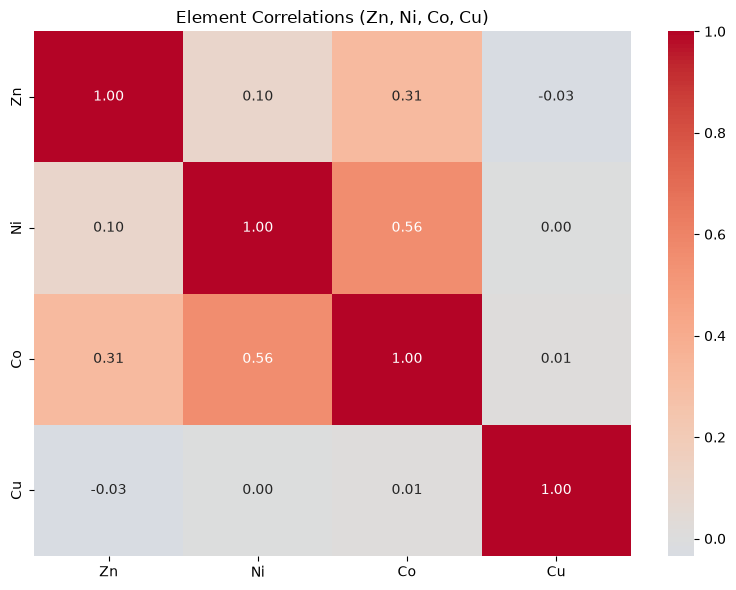


=== SPATIAL STATISTICS ===
Latitude range: 27.6765 to 27.7287
Longitude range: 75.9008 to 75.9273

=== FEATURE IMPORTANCE ===


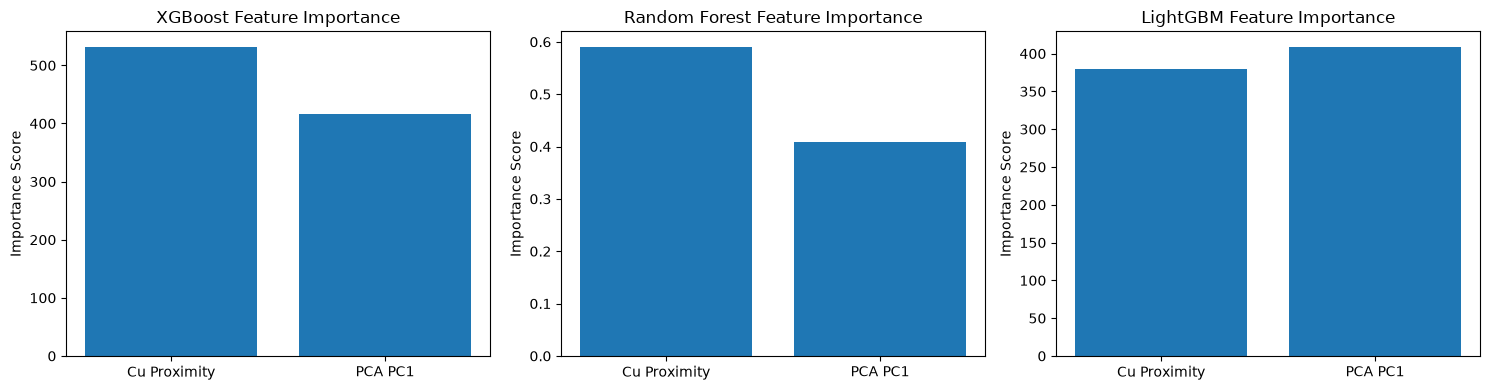


=== ELEMENT ANALYSIS BY CU PRESENCE ===

Zn statistics:
             count        mean         std  min    25%   50%     75%     max
Cu_presence                                                                 
0             74.0   59.148649   43.695297  4.0  32.25  44.5   71.25   190.0
1            290.0  109.293103  401.896267  5.0   36.0  56.5  119.75  6500.0

Ni statistics:
             count       mean        std   min   25%   50%    75%    max
Cu_presence                                                             
0             74.0  40.540541  10.823856  24.0  34.0  43.0  48.75   59.0
1            290.0  41.713793  13.049976  24.0  32.0  41.0   50.0  119.0

Co statistics:
             count       mean       std   min   25%   50%   75%   max
Cu_presence                                                          
0             74.0  27.418919   3.37195  24.0  24.0  27.0  30.0  36.0
1            290.0  26.406897  3.695123  24.0  24.0  25.0  28.0  55.0

Cu statistics:
             co

In [12]:
# ===== ADDITIONAL ANALYTICS & INSIGHTS =====
print("\n=== BRS REPORT DATA ANALYTICS ===")

# Element correlations
element_cols = [e for e in elements if e in df.columns]
if len(element_cols) > 1:
    corr_matrix = df[element_cols].corr()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
    ax.set_title('Element Correlations (Zn, Ni, Co, Cu)')
    plt.tight_layout()
    plt.show()

# Spatial analysis
print("\n=== SPATIAL STATISTICS ===")
print(f"Latitude range: {df['latitude'].min():.4f} to {df['latitude'].max():.4f}")
print(f"Longitude range: {df['longitude'].min():.4f} to {df['longitude'].max():.4f}")

# Feature importance from ensemble components
print("\n=== FEATURE IMPORTANCE ===")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# XGBoost feature importance
xgb_importance = xgb_model.get_booster().get_score(importance_type='weight')
xgb_importance = {0: xgb_importance.get('f0', 0), 1: xgb_importance.get('f1', 0)}
axes[0].bar(['Cu Proximity', 'PCA PC1'], [xgb_importance.get(0, 0), xgb_importance.get(1, 0)])
axes[0].set_title('XGBoost Feature Importance')
axes[0].set_ylabel('Importance Score')

# Random Forest feature importance
rf_importance = rf_model.feature_importances_
axes[1].bar(['Cu Proximity', 'PCA PC1'], rf_importance)
axes[1].set_title('Random Forest Feature Importance')
axes[1].set_ylabel('Importance Score')

# LightGBM feature importance
lgb_importance = lgb_model.feature_importances_
axes[2].bar(['Cu Proximity', 'PCA PC1'], lgb_importance)
axes[2].set_title('LightGBM Feature Importance')
axes[2].set_ylabel('Importance Score')

plt.tight_layout()
plt.show()

# Element distribution by Cu presence
print("\n=== ELEMENT ANALYSIS BY CU PRESENCE ===")
for elem in element_cols:
    print(f"\n{elem} statistics:")
    print(train_val_data.groupby('Cu_presence')[elem].describe())

print("\n✓ All analytics complete")

In [ ]:
# import pickle
# import os

# # Create output directory if it doesn't exist
# output_dir = r'C:\Users\Asus\OneDrive\Desktop\REE\data\processed'
# os.makedirs(output_dir, exist_ok=True)

# # Save results
# val_results.to_csv(os.path.join(output_dir, 'validation_predictions.csv'), index=False)
# test_results.to_csv(os.path.join(output_dir, 'test_predictions.csv'), index=False)

# # Save models
# with open(os.path.join(output_dir, 'ensemble_model.pkl'), 'wb') as f:
#     pickle.dump(ensemble_model, f)

# with open(os.path.join(output_dir, 'pca_scaler.pkl'), 'wb') as f:
#     pickle.dump((scaler, pca), f)

# # Save parameters for reference
# params = {
#     'N': N,
#     'k': k,
#     'm_max': m_max,
#     'center_lat': center_lat,
#     'center_lon': center_lon,
#     'elements_used': available_elements,
#     'feature_names': ['feature_cu_proximity', 'feature_pca_pc1']
# }

# with open(os.path.join(output_dir, 'model_parameters.pkl'), 'wb') as f:
#     pickle.dump(params, f)

# print(f"✓ Results saved to {output_dir}")
# print(f"  - validation_predictions.csv")
# print(f"  - test_predictions.csv")
# print(f"  - ensemble_model.pkl")
# print(f"  - pca_scaler.pkl")
# print(f"  - model_parameters.pkl")

# print("\n=== SUMMARY ===")
# print(f"Validation accuracy: {(val_results['actual_cu_presence'] == val_results['predicted_cu_presence']).mean():.2%}")
# print(f"Test set predictions: {len(test_results)} locations with Cu presence probability")
# print(f"\nNext steps:")
# print(f"1. Analyze spatial patterns of predictions")
# print(f"2. Optimize N and k parameters using cross-validation")
# print(f"3. Compare with existing geological maps")
# print(f"4. Deploy model for real-world copper exploration")